# PASO 4 — Calibración, diagnósticos y explicabilidad 

**Examen Parcial 3 · UNI**

1. Calibración post-hoc (Platt / isotónica) — ECE y Brier antes/después
2. Ablación por componente middleware (Gate B, fuzzy, RAG, ejes 4D)
3. Explicabilidad — permutation importance sobre overrides
4. Sub-análisis piloto n=40 CrewAI (sin reclamar n=400)

**Salvedad metodológica:** Var1 = 10 % CrewAI real (D5) + 90 % abstención pausa (Chow 1970). Var2 es la contribución principal. No se escala CrewAI a n=400 por costo/evidencia; sub-análisis n=40 documenta capacidad del agente.

Ejecutar primero: `run_calibracion_diagnosticos.py` (lee cache PASO 3, sin re-API).


In [1]:
from pathlib import Path
import subprocess
import sys

ROOT = Path(".").resolve()
script = ROOT / "run_calibracion_diagnosticos.py"
result = subprocess.run([sys.executable, str(script)], cwd=ROOT, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise SystemExit(result.returncode)


PASO 4 completado.
Calibración (ECE isotónica n=400):
  Baseline: 0.4477 → 0.0032
  Var1: 0.4400 → 0.0350
  Var2: 0.4193 → 0.0261
Ablación peor F1-stop: sin_gate_b
Piloto CrewAI n=40



In [2]:
import json
from pathlib import Path

import pandas as pd

ROOT = Path(".").resolve()
cal = pd.read_csv(ROOT / "1_tabla_calibracion_ece_brier_antes_despues.csv")
abl = pd.read_csv(ROOT / "3_tabla_ablacion_componentes_middleware.csv")
imp = pd.read_csv(ROOT / "5_tabla_importancia_senales_overrides.csv")
pilot = pd.read_csv(ROOT / "7_tabla_metricas_piloto_crewai_n40.csv")
resumen = json.loads((ROOT / "8_informe_resumen_paso4.json").read_text(encoding="utf-8"))

display(cal.groupby(["variante", "fase", "metodo_calibracion"])[["ECE", "Brier"]].first())
display(abl[["componente_ablado", "F1-stop", "EC", "override_rate", "delta_F1-stop", "delta_EC"]])
display(imp.head(8))
display(pilot[["n_piloto", "F1-macro (Macro-averaged F1)", "F1-stop (F1-critical)", "FNR-stop (False Negative Rate stop)"]])
print(json.dumps(resumen["calibracion_resumen"], indent=2))


ECE     Brier
variante fase    metodo_calibracion                    
Baseline antes   ninguno             0.447750  0.405200
         despues isotonic            0.003183  0.250007
                 platt               0.194379  0.210401
Var1     antes   ninguno             0.440000  0.312500
         despues isotonic            0.035000  0.170000
                 platt               0.101823  0.133154
Var2     antes   ninguno             0.419250  0.299800
         despues isotonic            0.026071  0.176423
                 platt               0.073382  0.156952

,componente_ablado,F1-stop,EC,override_rate,delta_F1-stop,delta_EC
0,ninguno (Var2 completo),0.390805,0.12315,0.165,0.000000,0.0000
1,sin_gate_b,0.057143,0.14675,0.000,-0.333662,0.0236
2,sin_fuzzy,0.390805,0.12315,0.165,0.000000,0.0000
3,sin_senal_rag,0.390805,0.12035,0.130,0.000000,-0.0028
4,sin_eje_I_sec,0.390805,0.12315,0.165,0.000000,0.0000
5,sin_eje_I_db,0.390805,0.12315,0.165,0.000000,0.0000


,senal,importancia_perm_media,importancia_perm_std,coef_logistic_override,peso_hpo_referencia,target
0,rag_uncertainty,0.028106,0.022741,-1.471102,0.142225,override_gate_b
1,class_consensus,0.002787,0.006010,-0.427506,0.103324,override_gate_b
2,I_mem,0.001355,0.001165,-0.262493,0.000000,override_gate_b
3,I_sec,0.000051,0.000847,0.102503,0.000000,override_gate_b
4,I_dat,-0.000012,0.000722,0.139154,0.000000,override_gate_b
5,neighbor_entropy,-0.000280,0.002464,-0.057799,0.071112,override_gate_b
6,I_db,-0.008888,0.020283,1.299887,0.000000,override_gate_b
7,risk_4d,-0.008999,0.012259,0.937956,0.230524,override_gate_b


,n_piloto,F1-macro (Macro-averaged F1),F1-stop (F1-critical),FNR-stop (False Negative Rate stop)
0,40,0.119369,0.25,0.666667


{
  "Baseline": {
    "ECE_antes": 0.44775,
    "ECE_despues_isotonic": 0.003183,
    "Brier_antes": 0.4052,
    "Brier_despues_isotonic": 0.250007,
    "delta_ECE": -0.444567
  },
  "Var1": {
    "ECE_antes": 0.44,
    "ECE_despues_isotonic": 0.035,
    "Brier_antes": 0.3125,
    "Brier_despues_isotonic": 0.17,
    "delta_ECE": -0.405
  },
  "Var2": {
    "ECE_antes": 0.41925,
    "ECE_despues_isotonic": 0.026071,
    "Brier_antes": 0.2998,
    "Brier_despues_isotonic": 0.176423,
    "delta_ECE": -0.393179
  }
}


## Figuras

Ver `2_figura_curvas_calibracion_tres_variantes.png`, `4_figura_ablacion_delta_f1_stop_ec.png`, `6_figura_importancia_senales_gate_b.png`.

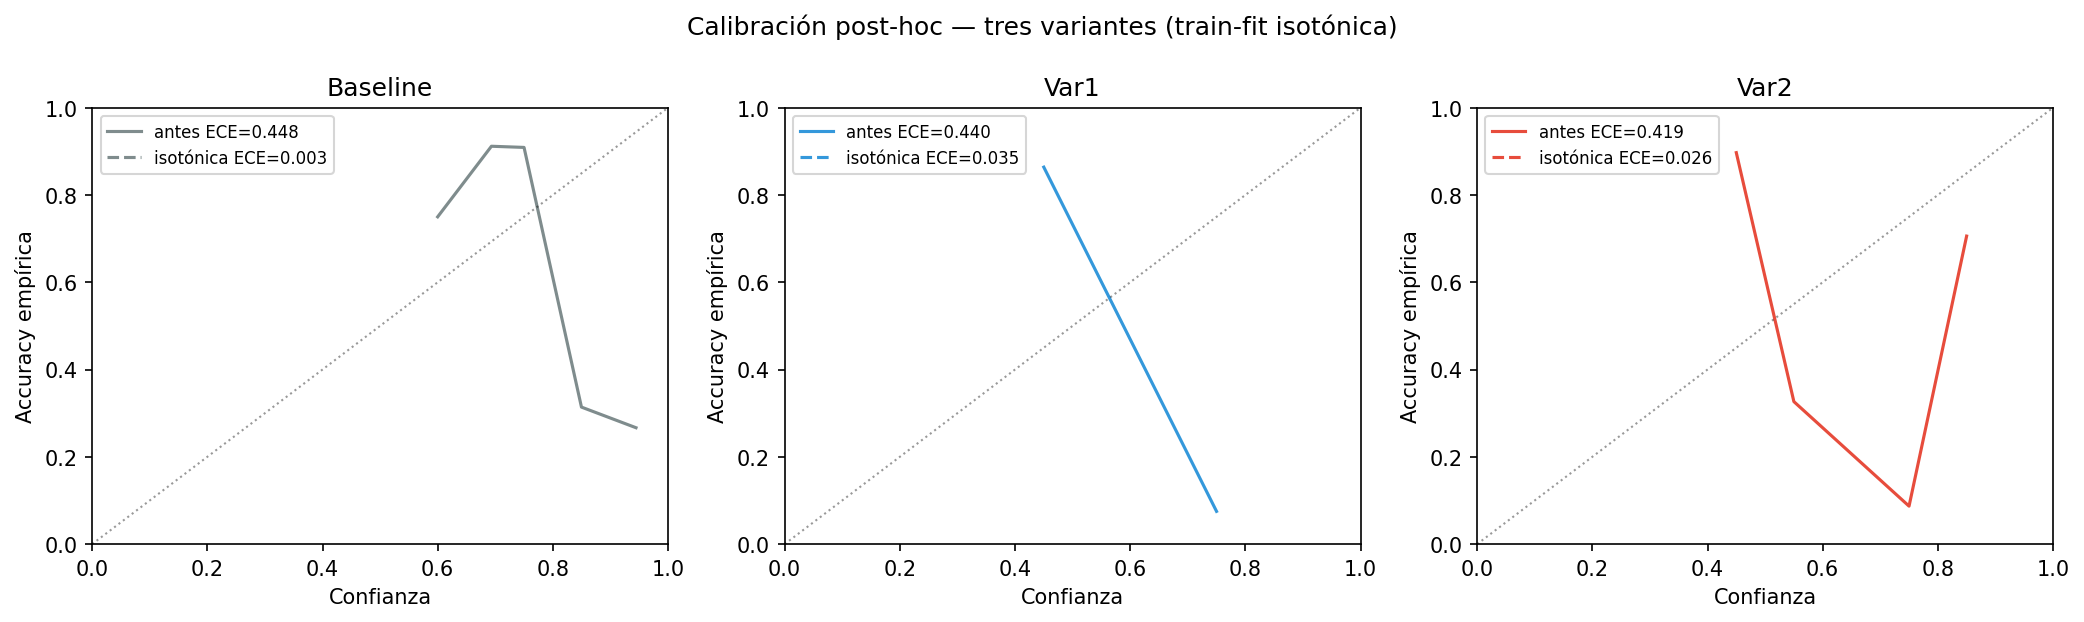

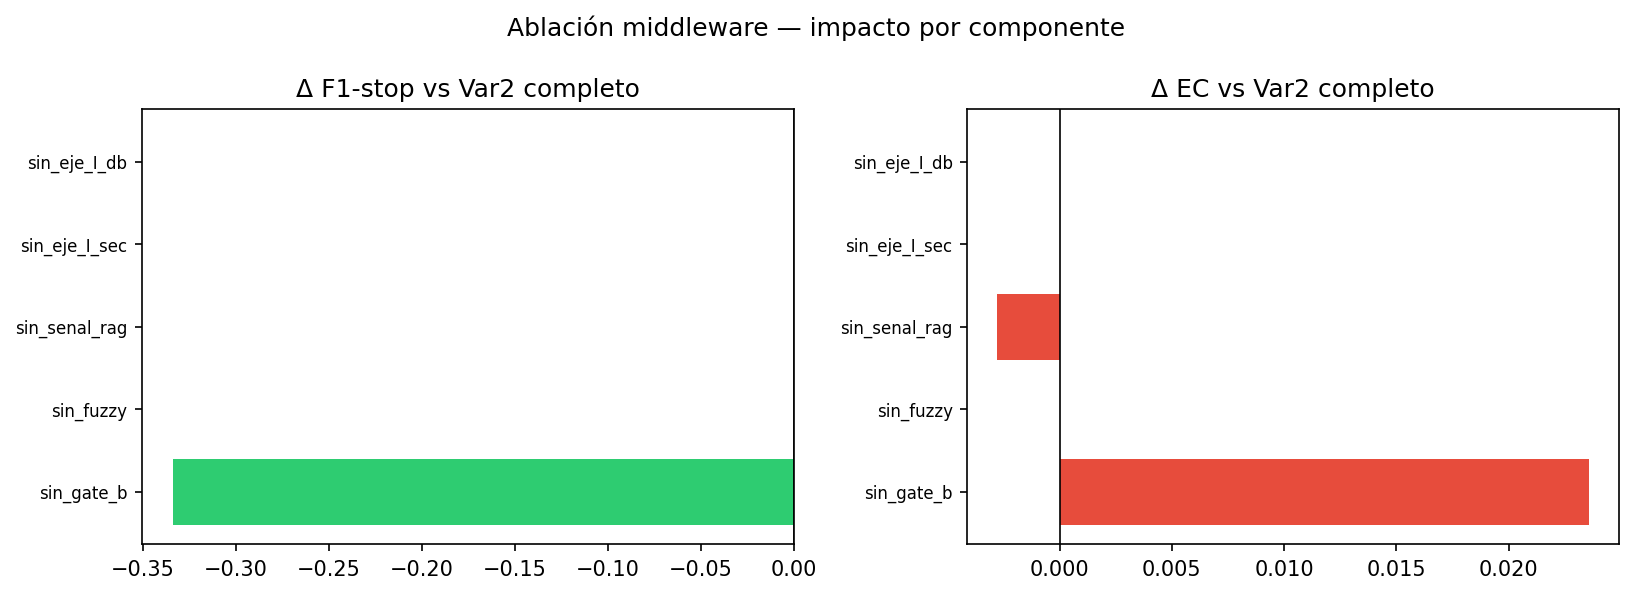

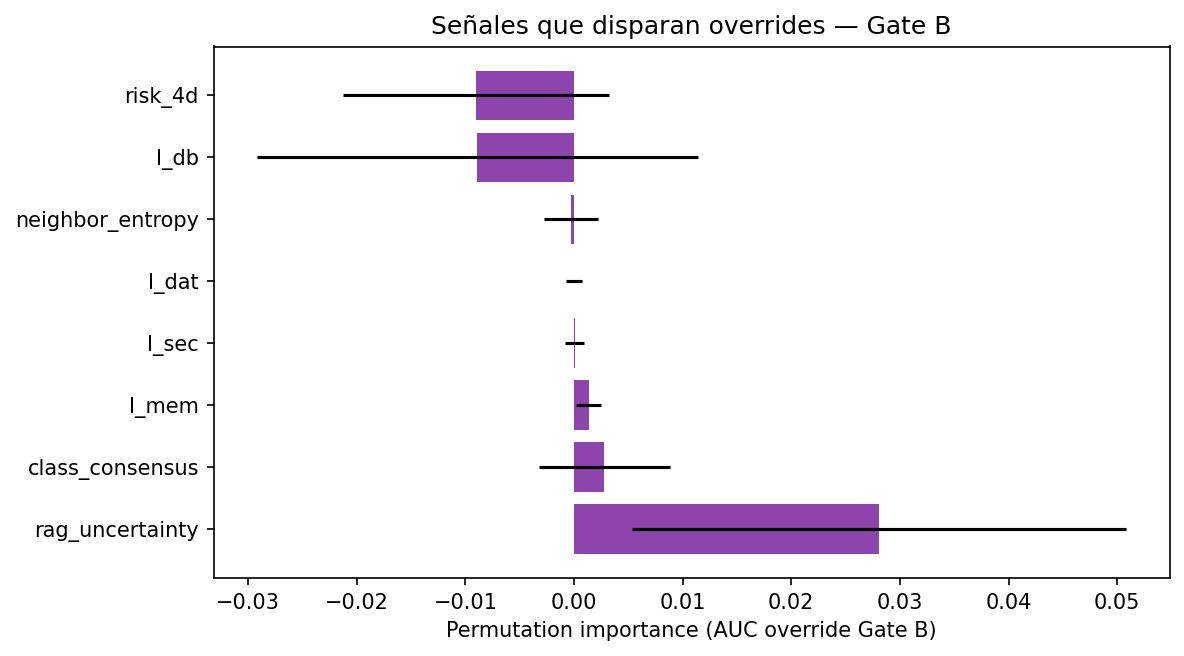

In [3]:
from IPython.display import Image, display
from pathlib import Path

ROOT = Path(".").resolve()
for fig in [
    "2_figura_curvas_calibracion_tres_variantes.png",
    "4_figura_ablacion_delta_f1_stop_ec.png",
    "6_figura_importancia_senales_gate_b.png",
]:
    p = ROOT / fig
    if p.exists():
        display(Image(filename=str(p)))
